In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["image.cmap"] = "gray"


In [4]:
SEQ = Path.home() / \
"HDD/EventDatasets/EVIMO2_official/flea3_7/imo/train/scene13_dyn_test_02_000000"

classical_file = SEQ / "dataset_classical.npz"

print(classical_file)

/home/ayon/HDD/EventDatasets/EVIMO2_official/flea3_7/imo/train/scene13_dyn_test_02_000000/dataset_classical.npz


In [5]:
classical = np.load(classical_file, allow_pickle=True)

print(type(classical))
print()

print("Keys")
print("="*80)

for key in classical.files:
    print(key)

<class 'numpy.lib.npyio.NpzFile'>

Keys
classical_0000000298
classical_0000000332
classical_0000000244
classical_0000000291
classical_0000000277
classical_0000000381
classical_0000000328
classical_0000000045
classical_0000000009
classical_0000000204
classical_0000000256
classical_0000000365
classical_0000000135
classical_0000000086
classical_0000000347
classical_0000000000
classical_0000000370
classical_0000000128
classical_0000000066
classical_0000000245
classical_0000000133
classical_0000000309
classical_0000000138
classical_0000000193
classical_0000000225
classical_0000000215
classical_0000000231
classical_0000000285
classical_0000000061
classical_0000000161
classical_0000000137
classical_0000000354
classical_0000000239
classical_0000000327
classical_0000000019
classical_0000000188
classical_0000000274
classical_0000000272
classical_0000000383
classical_0000000028
classical_0000000144
classical_0000000351
classical_0000000219
classical_0000000250
classical_0000000142
classical_00000

In [7]:
i = 0

for key in classical.files:
    if i==5:
        break
    i+=1
    x = classical[key]

    print("="*100)
    print(key)
    print("="*100)

    print("shape :", x.shape)
    print("dtype :", x.dtype)

    if x.ndim == 0:
        print()
        print("Scalar")
        print(x.item())

    elif np.issubdtype(x.dtype, np.number):

        print()
        print("min :", np.min(x))
        print("max :", np.max(x))

    if x.size < 20:
        print()
        print(x)

    else:

        print()
        print("first values")
        print(x[:5])

    print()


classical_0000000298
shape : (1552, 2080, 3)
dtype : uint8

min : 2
max : 241

first values
[[[40 47 80]
  [40 47 80]
  [44 54 84]
  ...
  [37 55 72]
  [36 54 71]
  [35 53 70]]

 [[40 48 78]
  [41 49 78]
  [45 53 82]
  ...
  [38 56 73]
  [36 54 71]
  [35 53 70]]

 [[42 49 74]
  [43 54 76]
  [43 54 76]
  ...
  [39 57 74]
  [37 55 72]
  [36 54 71]]

 [[46 54 71]
  [49 59 76]
  [45 55 72]
  ...
  [39 57 74]
  [39 57 74]
  [39 57 74]]

 [[49 58 68]
  [53 63 73]
  [47 57 67]
  ...
  [38 56 73]
  [40 58 75]
  [42 60 77]]]

classical_0000000332
shape : (1552, 2080, 3)
dtype : uint8

min : 1
max : 255

first values
[[[ 53  69 112]
  [ 50  66 108]
  [ 62  77 116]
  ...
  [ 24  29  30]
  [ 23  31  31]
  [ 23  31  31]]

 [[ 55  70 109]
  [ 50  66 103]
  [ 58  74 110]
  ...
  [ 24  29  30]
  [ 23  31  31]
  [ 23  31  31]]

 [[ 37  52  84]
  [ 34  50  79]
  [ 38  55  82]
  ...
  [ 24  29  30]
  [ 25  30  31]
  [ 25  30  31]]

 [[ 34  50  73]
  [ 34  51  72]
  [ 37  54  73]
  ...
  [ 24  29  30]
  [

In [8]:
keys = sorted(classical.files)

print("Number of RGB images:", len(keys))

print()

print("First 20 keys")

for k in keys[:20]:
    print(k)

print()

print("Last 20 keys")

for k in keys[-20:]:
    print(k)

Number of RGB images: 384

First 20 keys
classical_0000000000
classical_0000000001
classical_0000000002
classical_0000000003
classical_0000000004
classical_0000000005
classical_0000000006
classical_0000000007
classical_0000000008
classical_0000000009
classical_0000000010
classical_0000000011
classical_0000000012
classical_0000000013
classical_0000000014
classical_0000000015
classical_0000000016
classical_0000000017
classical_0000000018
classical_0000000019

Last 20 keys
classical_0000000364
classical_0000000365
classical_0000000366
classical_0000000367
classical_0000000368
classical_0000000369
classical_0000000370
classical_0000000371
classical_0000000372
classical_0000000373
classical_0000000374
classical_0000000375
classical_0000000376
classical_0000000377
classical_0000000378
classical_0000000379
classical_0000000380
classical_0000000381
classical_0000000382
classical_0000000383


In [9]:
frame_ids = []

for k in sorted(classical.files):

    frame_ids.append(int(k.split("_")[-1]))

frame_ids = np.array(frame_ids)

print(frame_ids[:20])

print()

print("Minimum :", frame_ids.min())
print("Maximum :", frame_ids.max())

print()

print("Average increment :", np.mean(np.diff(frame_ids)))

print("Unique increments")

print(np.unique(np.diff(frame_ids)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Minimum : 0
Maximum : 383

Average increment : 1.0
Unique increments
[1]


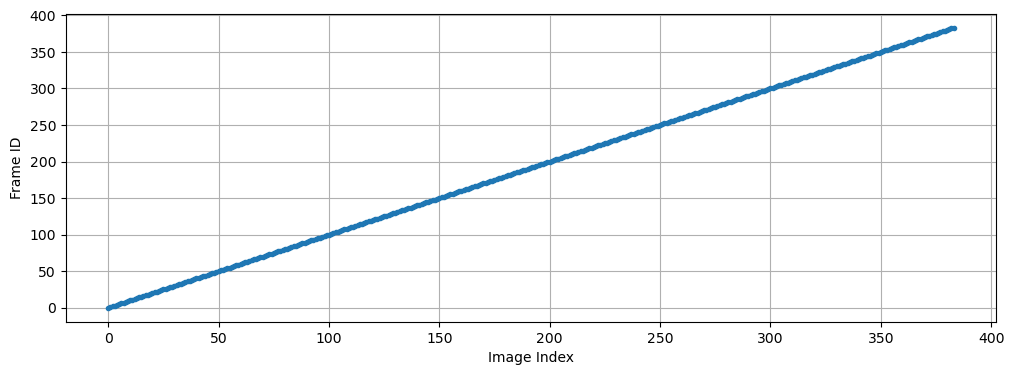

In [10]:
plt.figure(figsize=(12,4))

plt.plot(frame_ids, ".")

plt.xlabel("Image Index")
plt.ylabel("Frame ID")

plt.grid(True)

plt.show()

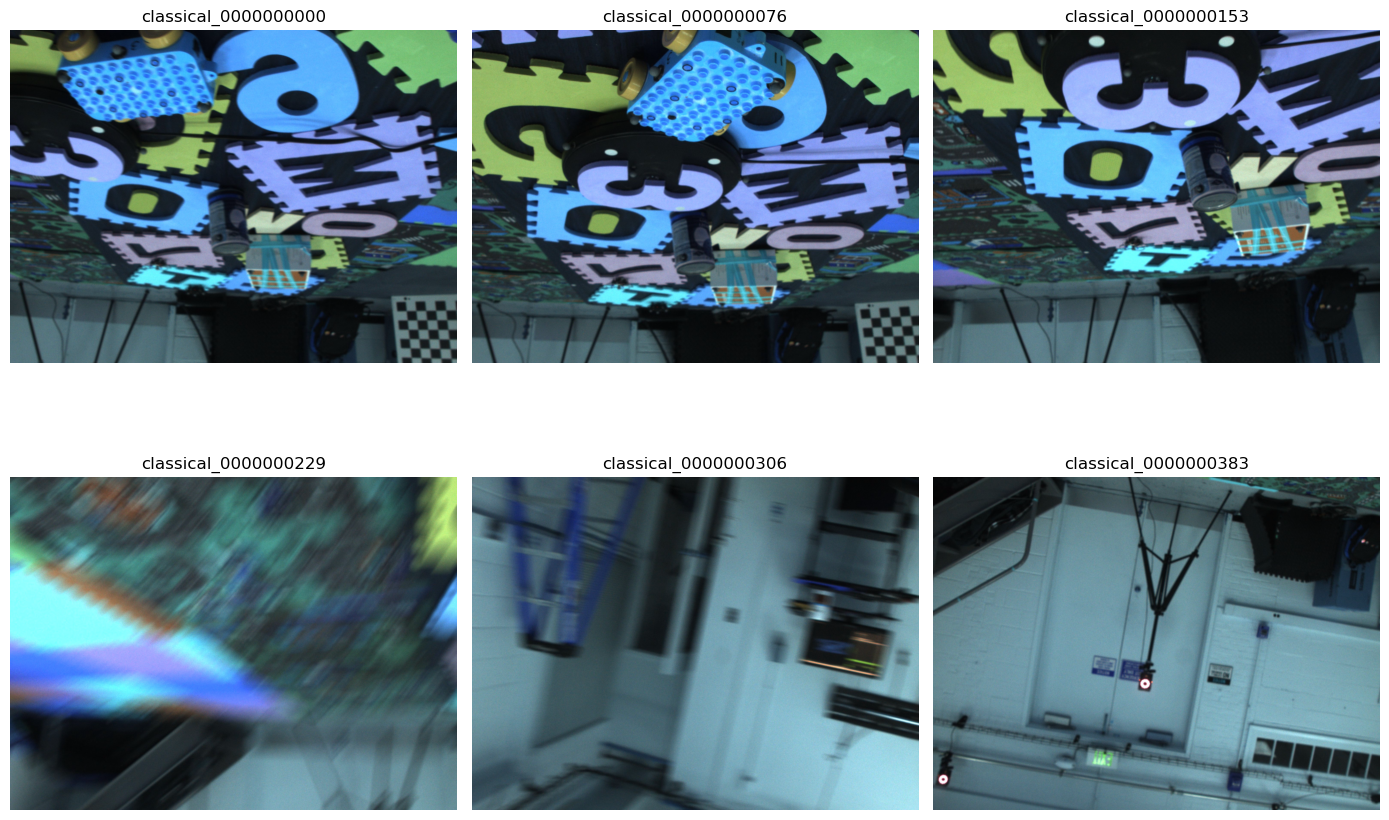

In [11]:
fig, ax = plt.subplots(2,3, figsize=(14,10))

indices = np.linspace(0, len(keys)-1, 6, dtype=int)

for axis, idx in zip(ax.ravel(), indices):

    img = classical[keys[idx]]

    axis.imshow(img)

    axis.set_title(keys[idx])

    axis.axis("off")

plt.tight_layout()
plt.show()

In [12]:
SEQ = Path.home() / \
"HDD/EventDatasets/EVIMO2_official/left_camera/imo/train/scene13_dyn_test_02_000000"

depth = np.load(
    SEQ / "dataset_depth.npz",
    allow_pickle=True
)

print(type(depth))

<class 'numpy.lib.npyio.NpzFile'>


In [13]:
print("="*80)
print("Keys")
print("="*80)

for key in depth.files:
    print(key)

print()
print("Total keys:", len(depth.files))

Keys
depth_0000000046
depth_0000000462
depth_0000000461
depth_0000000153
depth_0000000106
depth_0000000218
depth_0000000029
depth_0000000002
depth_0000000762
depth_0000000742
depth_0000000680
depth_0000000147
depth_0000000433
depth_0000000178
depth_0000000109
depth_0000000596
depth_0000000592
depth_0000000768
depth_0000000044
depth_0000000092
depth_0000000040
depth_0000000125
depth_0000000568
depth_0000000663
depth_0000000019
depth_0000000206
depth_0000000001
depth_0000000225
depth_0000000709
depth_0000000202
depth_0000000561
depth_0000000144
depth_0000000452
depth_0000000546
depth_0000000283
depth_0000000238
depth_0000000740
depth_0000000377
depth_0000000434
depth_0000000699
depth_0000000703
depth_0000000118
depth_0000000138
depth_0000000341
depth_0000000403
depth_0000000389
depth_0000000252
depth_0000000071
depth_0000000491
depth_0000000411
depth_0000000098
depth_0000000460
depth_0000000715
depth_0000000180
depth_0000000323
depth_0000000710
depth_0000000262
depth_0000000412
depth_000

In [17]:
import random
import numpy as np

keys = list(depth.files)

for key in random.sample(keys, 5):

    d = depth[key]

    print("=" * 100)
    print(key)
    print("=" * 100)

    print("Shape :", d.shape)
    print("Dtype :", d.dtype)

    valid = d[d > 0]

    print("Min depth :", d.min())
    print("Max depth :", d.max())

    print("Valid pixels :", valid.size)

    print("Zero pixels :", np.sum(d == 0))

    if valid.size > 0:
        print("Valid depth min :", valid.min())
        print("Valid depth max :", valid.max())
        print("Mean depth :", valid.mean())

depth_0000000242
Shape : (480, 640)
Dtype : uint16
Min depth : 0
Max depth : 1702
Valid pixels : 198970
Zero pixels : 108230
Valid depth min : 242
Valid depth max : 1702
Mean depth : 560.4980097502136
depth_0000000469
Shape : (480, 640)
Dtype : uint16
Min depth : 0
Max depth : 865
Valid pixels : 1292
Zero pixels : 305908
Valid depth min : 675
Valid depth max : 865
Mean depth : 732.1633126934985
depth_0000000412
Shape : (480, 640)
Dtype : uint16
Min depth : 0
Max depth : 1703
Valid pixels : 245718
Zero pixels : 61482
Valid depth min : 225
Valid depth max : 1703
Mean depth : 479.39801316956834
depth_0000000097
Shape : (480, 640)
Dtype : uint16
Min depth : 0
Max depth : 1852
Valid pixels : 186874
Zero pixels : 120326
Valid depth min : 267
Valid depth max : 1852
Mean depth : 564.606820638505
depth_0000000017
Shape : (480, 640)
Dtype : uint16
Min depth : 0
Max depth : 1874
Valid pixels : 181079
Zero pixels : 126121
Valid depth min : 276
Valid depth max : 1874
Mean depth : 591.4826401736259


In [18]:
print("Number of depth maps :", len(depth.files))

indices = sorted(int(k.split("_")[-1]) for k in depth.files)

print("\nFirst 20 indices")
print(indices[:20])

print("\nLast 20 indices")
print(indices[-20:])

print("\nMinimum index :", min(indices))
print("Maximum index :", max(indices))

print("\nMissing indices :", (max(indices)+1) - len(indices))

Number of depth maps : 750

First 20 indices
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Last 20 indices
[762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 780, 781]

Minimum index : 0
Maximum index : 781

Missing indices : 32


In [19]:
shapes = set()
dtypes = set()

for key in depth.files:

    x = depth[key]

    shapes.add(x.shape)
    dtypes.add(x.dtype)

print("Unique shapes")
print(shapes)

print()

print("Unique dtypes")
print(dtypes)

Unique shapes
{(480, 640)}

Unique dtypes
{dtype('uint16')}


In [20]:
mins = []
maxs = []
means = []

for key in depth.files:

    img = depth[key]

    valid = img[img > 0]

    if valid.size == 0:
        continue

    mins.append(valid.min())
    maxs.append(valid.max())
    means.append(valid.mean())

print("Global statistics")

print("Nearest depth :", min(mins))
print("Farthest depth :", max(maxs))
print("Average scene depth :", np.mean(means))

Global statistics
Nearest depth : 223
Farthest depth : 2685
Average scene depth : 909.514246385869


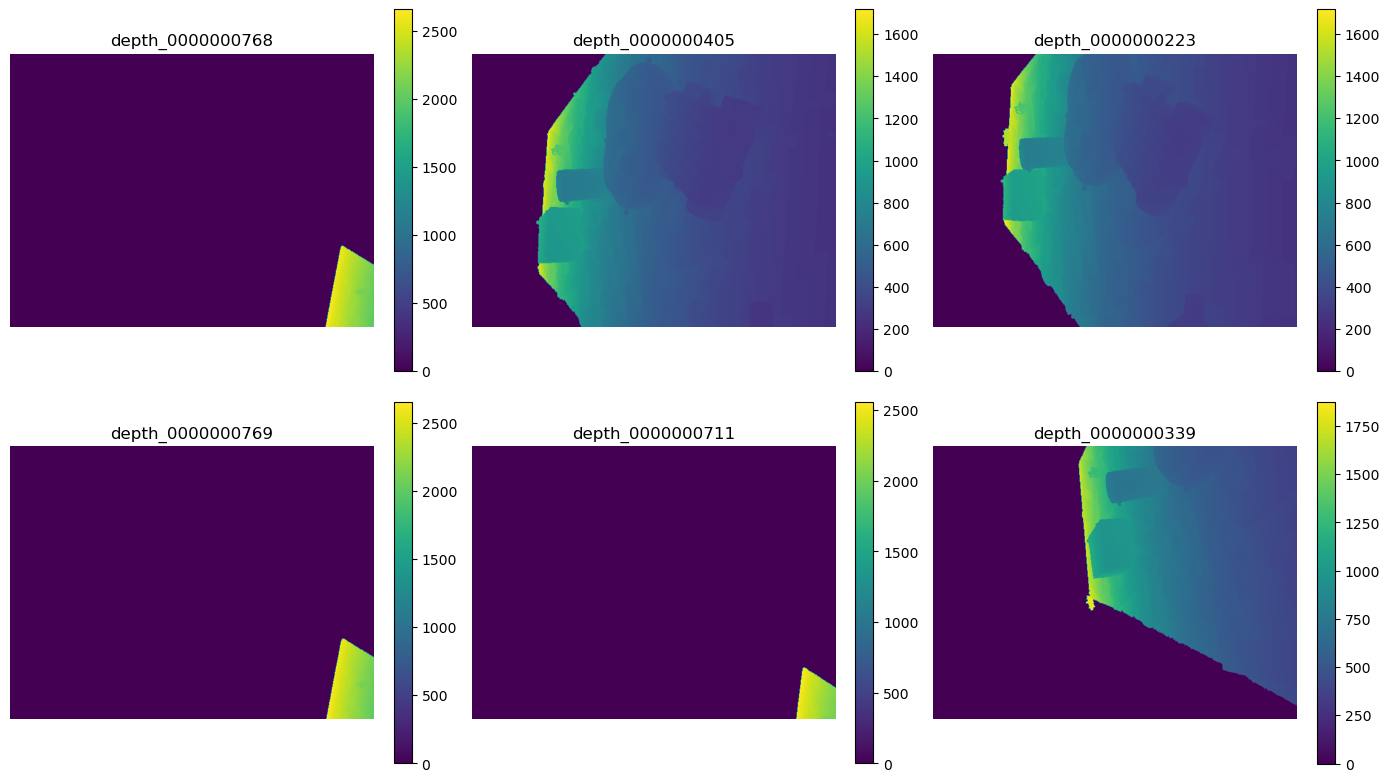

In [21]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 3, figsize=(14,8))

for ax, key in zip(axes.ravel(), random.sample(depth.files, 6)):

    img = depth[key]

    im = ax.imshow(img, cmap="viridis")

    ax.set_title(key)
    ax.axis("off")

    plt.colorbar(im, ax=ax, fraction=0.045)

plt.tight_layout()

In [22]:
indices = sorted(int(k.split("_")[-1]) for k in depth.files)

print("Average increment :", np.mean(np.diff(indices)))

print("Unique increments")
print(np.unique(np.diff(indices)))

Average increment : 1.0427236315086783
Unique increments
[ 1  2  3  7 24]


In [25]:
indices = sorted(int(k.split("_")[-1]) for k in depth.files)

print(indices[:50])

print()

max(np.diff(indices))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]



np.int64(24)